## Cеминар 2. Генерация текста


#### План

1. Токенизация
2. RNN
3. Метрики качества генерации

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import re
import pandas as pd
import numpy as np
import torch
from tokenizers import Tokenizer, models, trainers
from tokenizers.normalizers import Lowercase
from tokenizers.pre_tokenizers import Whitespace
from tokenizers.processors import TemplateProcessing
from tokenizers.decoders import WordPiece as WordPieceDecoder
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from functools import partial
from collections import Counter


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

### Токенизация

Токенизация – процесс разбиения текста на подстроки (токены). Токенизация в первую очередь нужна для уменьшения размера словаря. При этом при токенизации мы хотим, чтобы все токены были максимально репрезентативными. Таким образом, мы балансируем между размером словаря и репрезентативностью токенов.

In [3]:
from tokenizers import Tokenizer, models

tokenizer = Tokenizer(models.BPE())

Токенизация включает в себя несколько компонент:

1. **Нормализация** - предварительную очистку текста (приведение к нижнему регистру, замена unicode символов на ascii и т.д.)

In [4]:
from tokenizers import normalizers
from tokenizers.normalizers import NFD, StripAccents, Lowercase, Strip

normalizer = normalizers.Sequence([NFD(), StripAccents(), Lowercase(), Strip()])
normalizer.normalize_str(" Héllò hôw are ü?")

'hello how are u?'

In [5]:
tokenizer.normalizer = normalizer

2. **Предварительная токенизация** — процесс разбиения текста на более мелкие фрагменты, задающие верхнюю границу того, какими будут токены в токенизации. Обычно предварительная токенизация разобивает текст на слова. Тогда итоговые токены будут частями этих слов.

In [6]:
from tokenizers.pre_tokenizers import Whitespace

pre_tokenizer = Whitespace()
pre_tokenizer.pre_tokenize_str("Hello! How are you? I'm fine, thank you.")

[('Hello', (0, 5)),
 ('!', (5, 6)),
 ('How', (7, 10)),
 ('are', (11, 14)),
 ('you', (15, 18)),
 ('?', (18, 19)),
 ('I', (20, 21)),
 ("'", (21, 22)),
 ('m', (22, 23)),
 ('fine', (24, 28)),
 (',', (28, 29)),
 ('thank', (30, 35)),
 ('you', (36, 39)),
 ('.', (39, 40))]

Заметьте, что строка "I'm" разбилась на ["I", "'", "m"]. Это может быть не очень хорошо, учитывая, что "'m" – то же самое, что "am". Для более "правильного" разбиения можно использовать претокенизацию на основе правил. Самые популярные инструменты для этого – `spaCy` и `Moses`.

In [7]:
tokenizer.pre_tokenizer = pre_tokenizer

3. **Модель** – главная часть токенизации. Модель необходимо обучать на корпусе текстов, чтобы получить словарь, подходящий под конкретные данные. Она применяется к результату претокенизации. И ее задача – разбить "слова" на более мелкие составляющие согласно выученным правилам.

Наиболее распространенные виды моделей: `BPE`, `WordPiece`, `Unigram`.

#### Byte-Pair Encoding (BPE)

__Алгоритм обучения:__

1. Считаем, сколько раз каждое слово встречается в корпусе
2. Создаем словарь токенов, который пока что состоит из всех уникальных символов
3. Находим пару токенов, которая чаще всего встречается вместе. Склеиваем ее в токен и добавляем в словарь.
4. Повторяем 3, пока словарь не достигнет нужного размера.


__Пример:__

Корпус слов со встречаемостями: (`("hug", 2)`, `("pug", 1)`, `("pun", 4)`, `("bun", 3)`, `("hugs", 1)`)   
Максимальный размер словаря – __9__.

__Шаг 1.__    
Словарь: [`"b"`, `"g"`, `"h"`, `"n"`, `"p"`, `"s"`, `"u"`], размер: __7__.   
Корпус: [`("h" "u" "g", 3)`, `("p" "u" "g", 1)`, `("p" "u" "n", 3)`, `("b" "u" "n", 3)`, `("h" "u" "g" "s", 1)`]

Чаще всего встречается пара (`"u" "n"`) – 6 раз. Добавляем ее в словарь и обновляем корпус.

__Шаг 2.__    
Словарь: [`"b"`, `"g"`, `"h"`, `"n"`, `"p"`, `"s"`, `"u"`, `"un"`], размер: __8__.   
Корпус: [`("h" "u" "g", 3)`, `("p" "u" "g", 1)`, `("p" "un", 3)`, `("b" "un", 3)`, `("h" "u" "g" "s", 1)`]

Чаще всего встречается пара (`"u" "g"`) – 5 раз. Добавляем ее в словарь и обновляем корпус.

__Шаг 3.__    
Словарь: [`"b"`, `"g"`, `"h"`, `"n"`, `"p"`, `"s"`, `"u"`, `"un"`, `"ug"`], размер: __9__.    
Корпус: [`("h" "ug", 3)`, `("p" "ug", 1)`, `("p" "un", 3)`, `("b" "un", 3)`, `("h" "ug" "s", 1)`]


__Процесс токенизации:__

1. Нормализация
1. Предварительная токенизация
1. Разделение слов на отдельные символы
1. Применение правил слияния (в порядке их появления в словаре) к разделенным словам 


#### Byte-level BPE

Если вы собираетесь обучать очень большую модель на всем интернете, то вы можете столкнуться с ситуацией, в которой на тестовой выборке попадаются токены не из словаря (например, эмоджи). В таком случае токены придется менять на UNK и терять эту информацию.

Токенизаторы GPT-2 и RoBERTa (которые довольно похожи) имеют умный способ решения этой проблемы: они рассматривают слова не как символы Unicode, а как байты. Таким образом, базовый словарь имеет небольшой размер (256), но все символы, которые вы можете придумать, все равно будут включены и не будут преобразованы в неизвестный токен. Этот трюк называется byte-level BPE.

#### WordPiece

WordPiece работает точно так же, как и BPE, за исключением выбора токенов для слияния. BPE не учитывает частоту встречаемости каждого из токенов по отдельности. WordPiece же исправляет это и вводит score, по которому оценивает необходимоть слияния двух токенов

$$
\operatorname{score}=\frac{\text{freq of pair}}{\text{freq of first element}\times \text{freq of second element}}
$$

In [8]:
from tokenizers import trainers

texts = [
    "An infinite number of mathematicians walk into a bar.",
    "The first one orders one beer. The second one - half a pint, the third one - a quarter.",
    "– Hey, hey, hey, stop! Here are two pints for everyone, and leave me alone!"
]

trainer = trainers.BpeTrainer(
    vocab_size=128, min_frequency=1,
    special_tokens=['[BOS]', '[EOS]'],
    continuing_subword_prefix='##',  # add special prefix to allow detokenization
)
tokenizer.train_from_iterator(texts, trainer)

In [9]:
tokenized = tokenizer.encode("An infinite number of mathematicians walk into a bar.")
print('Tokens:', tokenized.tokens)
print('Ids:', tokenized.ids)

Tokens: ['an', 'infi', '##ni', '##te', 'numb', '##er', 'of', 'mathem', '##atici', '##ans', 'wal', '##k', 'into', 'a', 'bar', '.']
Ids: [58, 121, 91, 100, 125, 51, 81, 124, 111, 94, 87, 49, 122, 6, 69, 5]


4. __Пост-обработка__ – последний шаг токенизации. Нужен для того, чтобы как-то изменить токенизированный текст. Например, чтобы добавить токены начала и конца последовательности.

In [10]:
from tokenizers.processors import TemplateProcessing

post_processor = TemplateProcessing(
    single="[BOS] $A [EOS]",
    special_tokens=[("[BOS]", 1), ("[EOS]", 2)],
)

In [11]:
processed = post_processor.process(tokenized)
print('Tokens:', processed.tokens)
print('Ids:', processed.ids)

Tokens: ['[BOS]', 'an', 'infi', '##ni', '##te', 'numb', '##er', 'of', 'mathem', '##atici', '##ans', 'wal', '##k', 'into', 'a', 'bar', '.', '[EOS]']
Ids: [1, 58, 121, 91, 100, 125, 51, 81, 124, 111, 94, 87, 49, 122, 6, 69, 5, 2]


In [12]:
tokenizer.decoder = WordPieceDecoder(prefix='##', cleanup=True)

In [13]:
tokenizer.decode(tokenized.ids)

'an infinite number of mathematicians walk into a bar.'

### Обработка данных

In [14]:
from datasets import load_from_disk

dataset = load_from_disk('fake_news_clean')
dataset = dataset.train_test_split(test_size=0.1, seed=42)

In [15]:
train_texts = np.array(dataset['train']['text'])
test_texts = np.array(dataset['test']['text'])

In [16]:
def print_texts(texts):
    for t in texts:
        print(t, end='\n\n')

In [17]:
idxs = [5, 9]
print_texts(train_texts[idxs])

Иосиф Пригожин организовал турне по Африке для певицы Валерии

The International 2023 пойдет в Уфе



In [18]:
from my_tokenizers import *

In [19]:
tok = CharacterTokenizer(train_texts)

tokenized = tok.encode(train_texts[idxs])
print('Tokenized')
print_texts(tokenized['tokens'])
print('Detokenized')
print_texts(tok.decode(tokenized['input_ids']))

print(f'Vocab size: {len(tok.token2id)}')

Tokenized
['[BOS]', 'и', 'о', 'с', 'и', 'ф', ' ', 'п', 'р', 'и', 'г', 'о', 'ж', 'и', 'н', ' ', 'о', 'р', 'г', 'а', 'н', 'и', 'з', 'о', 'в', 'а', 'л', ' ', 'т', 'у', 'р', 'н', 'е', ' ', 'п', 'о', ' ', 'а', 'ф', 'р', 'и', 'к', 'е', ' ', 'д', 'л', 'я', ' ', 'п', 'е', 'в', 'и', 'ц', 'ы', ' ', 'в', 'а', 'л', 'е', 'р', 'и', 'и', '[EOS]']

['[BOS]', 't', 'h', 'e', ' ', 'i', 'n', 't', 'e', 'r', 'n', 'a', 't', 'i', 'o', 'n', 'a', 'l', ' ', '2', '0', '2', '3', ' ', 'п', 'о', 'й', 'д', 'е', 'т', ' ', 'в', ' ', 'у', 'ф', 'е', '[EOS]']

Detokenized
иосиф пригожин организовал турне по африке для певицы валерии

the international 2023 пойдет в уфе

Vocab size: 364


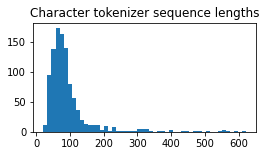

In [20]:
tokenized_lengths = [len(t) for t in tok.encode(test_texts)['tokens']]
plt.figure(figsize=(4, 2))
plt.hist(tokenized_lengths, bins=50)
plt.title('Character tokenizer sequence lengths')
plt.show()

In [21]:
tok = WordTokenizer(train_texts)

tokenized = tok.encode(train_texts[idxs])
print('Tokenized')
print_texts(tokenized['tokens'])
print('Detokenized')
print_texts(tok.decode(tokenized['input_ids']))

print(f'Vocab size: {len(tok.token2id)}')

Tokenized
['[BOS]', 'иосиф', 'пригожин', 'организовал', 'турне', 'по', 'африке', 'для', 'певицы', 'валерии', '[EOS]']

['[BOS]', 'the', 'international', '2023', 'пойдет', 'в', 'уфе', '[EOS]']

Detokenized
иосиф пригожин организовал турне по африке для певицы валерии

the international 2023 пойдет в уфе

Vocab size: 28440


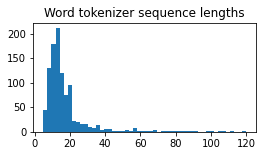

In [22]:
tokenized_lengths = [len(t) for t in tok.encode(test_texts)['tokens']]
plt.figure(figsize=(4, 2))
plt.hist(tokenized_lengths, bins=50)
plt.title('Word tokenizer sequence lengths')
plt.show()

In [23]:
tok = BPETokenizer(train_texts, vocab_size=4096)

tokenized = tok.encode(train_texts[idxs])
print('Tokenized')
print_texts(tokenized['tokens'])

print('Detokenized')
print_texts(tok.decode(tokenized['input_ids']))

print(f'Vocab size: {len(tok.token2id)}')

Tokenized
['[BOS]', 'и', '##ос', '##иф', 'пригожин', 'организ', '##овал', 'тур', '##не', 'по', 'аф', '##ри', '##ке', 'для', 'пев', '##и', '##цы', 'вал', '##ер', '##ии', '[EOS]']

['[BOS]', 'the', 'i', '##n', '##t', '##er', '##n', '##at', '##i', '##ona', '##l', '2023', 'по', '##йдет', 'в', 'уф', '##е', '[EOS]']

Detokenized
иосиф пригожин организовал турне по африке для певицы валерии

the international 2023 пойдет в уфе

Vocab size: 4096


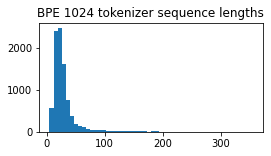

In [24]:
tokenized_lengths = [len(t) for t in tok.encode(train_texts)['tokens']]
plt.figure(figsize=(4, 2))
plt.hist(tokenized_lengths, bins=50)
plt.title('BPE 1024 tokenizer sequence lengths')
plt.show()

### Обучение RNN

In [25]:
import torch
import torch.nn as nn
from typing import Optional


class RNN(nn.Module):
    def __init__(self, vocab_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size

        self.embeddings = nn.Embedding(vocab_size, hidden_size)

        self.W = nn.Linear(hidden_size + hidden_size, hidden_size)
        self.O = nn.Linear(hidden_size, vocab_size)

    def forward(self, input_ids, h0: Optional[torch.Tensor] = None):
        batch_size, seq_len = input_ids.shape
        x = self.embeddings(input_ids)

        if h0 is None:
            h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
        else:
            h_t = h0

        outputs = []
        for t in range(seq_len):
            x_t = x[:, t, :]

            h_t = torch.tanh(
                self.W(torch.cat((x_t, h_t), dim=-1))
            )

            o_t = self.O(h_t)
            outputs.append(o_t)

        outputs = torch.stack(outputs, dim=1)

        return outputs, h_t

In [26]:
def train(model, dataloader, optimizer, loss_fn):
    model.train()

    accuracies = []
    for input_ids in dataloader:
        input_ids = input_ids.to(device)

        logits, _ = model(input_ids)
        
        shift_ids = input_ids[:, 1:]
        shift_logits = logits[:, :-1]
        loss = loss_fn(shift_logits.permute(0, 2, 1), shift_ids)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        accuracy = (shift_logits.argmax(-1) == shift_ids).float().mean().item()
        accuracies.append(accuracy)
    
    return np.mean(accuracies)


@torch.no_grad()
def evaluate(model, dataloader, loss_fn):
    model.eval()

    accuracies = []
    losses = []
    for input_ids in dataloader:
        input_ids = input_ids.to(device)

        logits, _ = model(input_ids)
        
        shift_ids = input_ids[:, 1:]
        shift_logits = logits[:, :-1]
        loss = loss_fn(shift_logits.permute(0, 2, 1), shift_ids)

        accuracies.append((shift_logits.argmax(-1) == shift_ids).float().mean().item())
        losses.append(loss.item())

    loss = np.mean(losses)
    accuracy = np.mean(accuracies)

    return accuracy, loss

In [27]:
from torch.distributions.categorical import Categorical


@torch.inference_mode()
def generate(tokenizer, model, batch_size=4, max_length=40):
    input_ids = torch.empty(size=(batch_size, 1), device=device).fill_(tokenizer.bos_token_id).int()
    h_t = torch.zeros(batch_size, model.hidden_size, device=device)
    gen_ids = []
    for i in range(max_length):
        logits, h_t = model(input_ids, h_t)
        input_ids = Categorical(logits=logits).sample()
        gen_ids.append(input_ids)
    
    return torch.cat(gen_ids, dim=1)

## Натренируем модели на разных токенизаторах

In [28]:
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader


def train_rnn_model(tokenizer):    
    def collate_fn(batch, max_length=None):
        tokens = tokenizer.encode(batch, max_length=max_length)['input_ids']
        return pad_sequence(tokens, padding_value=tokenizer.pad_token_id, batch_first=True)
    max_length = 50
    collate = partial(collate_fn, max_length=max_length)
    train_loader = DataLoader(train_texts, collate_fn=collate, shuffle=True, batch_size=128)
    test_loader = DataLoader(test_texts, collate_fn=collate, shuffle=False, batch_size=128)
    model = RNN(vocab_size=len(tokenizer), hidden_size=2048).to(device)

    print('Number of parameters:', sum(p.numel() for p in model.parameters()))

    optimizer = torch.optim.Adam(model.parameters(), lr=4e-4, weight_decay=1e-3)
    loss_fn = nn.CrossEntropyLoss(ignore_index=tokenizer.pad_token_id)
    
    for epoch in tqdm(range(20)):
        train_accuracy = train(model, train_loader, optimizer, loss_fn)
        test_accuracy, test_loss = evaluate(model, test_loader, loss_fn)
        if epoch % 5 == 0:
            print(train_accuracy, test_accuracy, test_loss)
    
    _, test_loss = evaluate(model, test_loader, loss_fn)
    
    return model, test_loss

In [29]:
torch.cuda.empty_cache()

In [30]:
bpe_tokenizer = BPETokenizer(corpus=train_texts, vocab_size=4096)
bpe_rnn, bpe_test_loss = train_rnn_model(bpe_tokenizer)
torch.save(bpe_rnn.state_dict(), 'checkpoints/bpe_rnn.pt')
# bpe_rnn = RNN(vocab_size=len(bpe_tokenizer), hidden_size=2048)
# bpe_rnn.load_state_dict(torch.load('checkpoints/bpe_rnn.pt', map_location='cpu'))
# bpe_rnn = bpe_rnn.to(device)

Number of parameters: 25171968


  0%|          | 0/20 [00:00<?, ?it/s]

0.04194905348898222 0.0672638756223023 5.765738308429718
0.15065510157081816 0.11964401137083769 4.666414976119995
0.19750863023930126 0.1261591436341405 4.629236698150635
0.2366006871064504 0.12719871010631323 4.707810759544373


In [31]:
word_tokenizer = WordTokenizer(corpus=train_texts, vocab_size=4096)
word_rnn, word_test_loss = train_rnn_model(word_tokenizer)
torch.save(bpe_rnn.state_dict(), 'checkpoints/word_rnn.pt')
# word_rnn = RNN(vocab_size=len(word_tokenizer), hidden_size=2048)
# word_rnn.load_state_dict(torch.load('checkpoints/word_rnn.pt', map_location='cpu'))
# word_rnn = word_rnn.to(device)

Number of parameters: 25171968


  0%|          | 0/20 [00:00<?, ?it/s]

0.07931896004306004 0.09527559578418732 4.490369737148285
0.1122479767849048 0.10803584009408951 3.947805255651474
0.12458888420628177 0.10768931824713945 3.938414454460144
0.13679846686621508 0.10793104767799377 3.9897395074367523


In [32]:
char_tokenizer = CharacterTokenizer(corpus=train_texts)
char_rnn, char_test_loss = train_rnn_model(char_tokenizer)
torch.save(bpe_rnn.state_dict(), 'checkpoints/char_rnn.pt')
# char_rnn = RNN(vocab_size=len(char_tokenizer), hidden_size=2048)
# char_rnn.load_state_dict(torch.load('checkpoints/char_rnn.pt', map_location='cpu'))
# char_rnn = char_rnn.to(device)

Number of parameters: 9881964


  0%|          | 0/20 [00:00<?, ?it/s]

0.2754342338303104 0.34629715234041214 2.2547012269496918
0.4759525598751174 0.48234472051262856 1.761116549372673
0.5171843336688148 0.5110475569963455 1.6507225632667542
0.5365958097908232 0.5274517461657524 1.601510301232338


In [34]:
bpe_outputs = generate(bpe_tokenizer, bpe_rnn, batch_size=5000)
word_outputs = generate(word_tokenizer, word_rnn, batch_size=5000)
char_outputs = generate(char_tokenizer, char_rnn, batch_size=5000)

# Метрики качества

## Валидационная перплексия
NLL:
$$
\text{NLL} = -\frac{1}{N} \sum_{i=1}^{N} \log P(x_i \mid x_{<i})
$$

Перплексия:
$$
\text{PPL} = \exp \left( \text{NLL} \right)
= \exp \left( -\frac{1}{N} \sum_{i=1}^{N} \log P(x_i \mid x_{<i}) \right)
$$

Казалось бы, идеальная метрика для замера качества. Модель должна хорошо распознавать качественные тексты

In [35]:
print("BPE model Val. PPL", np.exp(bpe_test_loss.item()))
print("WordPiece model Val. PPL", np.exp(word_test_loss.item()))
print("Character model Val. PPL", np.exp(char_test_loss.item()))

BPE model Val. PPL 125.69238200122754
WordPiece model Val. PPL 57.92903543843975
Character model Val. PPL 4.856640346550759


У валидационной переплексии есть несколько недостатков. 
1. Она не меряет непосредственно качество генерации
2. Модели, обученные на разных токенизаторах, нельзя сравнивать по валидационой перплексии, потому что она усредняется по длине. Поэтому для токенизатора с маленьким словарем перплексия будет всегда ниже, так как лосс отдельного токена ниже

# Генеративная перплексия

Те же яйца, только в профиль. 

Тут уже немного другой пайплайн оценки:
тексты генерируем нашей моделью, а их правдоподобия для NLL оцениваем какой-нибудь большой предобученной моделью (например, GPT2, который вы пройдете позже)

In [36]:
import evaluate

perplexity = evaluate.load("perplexity", module_type="metric", model_id="gpt2")

In [37]:
def compute_ppl(predictions):
    torch.cuda.empty_cache()
    ppl_list = perplexity.compute(
        predictions=predictions, 
        model_id="gpt2", 
        device="cuda", 
        add_start_token=True,
    )["perplexities"]
    ppl = np.mean(ppl_list)
    return ppl

In [38]:
bpe_model_ppl = compute_ppl(bpe_tokenizer.decode(bpe_outputs))
word_model_ppl = compute_ppl(word_tokenizer.decode(word_outputs))
char_model_ppl = compute_ppl(char_tokenizer.decode(char_outputs))

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

  0%|          | 0/313 [00:00<?, ?it/s]

In [39]:
print("BPE RNN generative PPL", bpe_model_ppl)
print("WordPiece RNN generative PPL", word_model_ppl)
print("Character RNN generative PPL", char_model_ppl)

BPE RNN generative PPL 12.853353723239898
WordPiece RNN generative PPL 11.81260601425171
Character RNN generative PPL 18.65658338756561


Генеративная перплексия достаточно хорошо умеет отличать плохие тексты от хороших. Однако ранжирование между качественных текстов уже не такое наглядное.

К тому же, поскольку как ground-truth оценка используется другая предобученная модель, она может ломаться:

In [40]:
compute_ppl(["#####.....###...                ......          ####.."])

  0%|          | 0/1 [00:00<?, ?it/s]

10.171130180358887

## MAUVE
Пожалуй, наиболее репрезентативная метрика, которой на практике мы пользуемся чаще всего. Считается достаточно хитро: каждый текст в сгенерированном корпусе и эталонном корпусе пропускают через предобученный энкодер (как правило, берут усредненный последний скрытый слой GPT2). Затем тексты кластеризуются k-means. А внутри каждого кластера между текстами сгенерированными и эталонными считается какое-то расстояние (в оригинальное статье использовали KL-дивергенцию). Таким образом, мы пытаемся оценить близость распределений текстов.

На нашей практике это одна из лучших метрик, которая очень хорошо коррелирует с качеством текстов. Она чувствительна к длине и "мусорным" токенам. Из недостатков разве что шумность - батч нужно брать достаточно большой - и невозможность применять к большим моделям

In [41]:
def compute_mauve(predictions, references, model_id='gpt2'):
    mauve = evaluate.load("mauve")
    assert len(predictions) == len(references)

    if len(predictions) == 0:
        return 0

    results = mauve.compute(
        predictions=predictions, references=references,
        featurize_model_name=model_id, device_id=0, verbose=False
    )

    return results.mauve

In [ ]:
print(compute_mauve(bpe_tokenizer.decode(bpe_outputs), test_texts[:5000]))
print(compute_mauve(char_tokenizer.decode(char_outputs), test_texts[:5000]))
print(compute_mauve(word_tokenizer.decode(word_outputs), test_texts[:5000]))

## Diversity

Еще одной простой, но важной метрикой, является разнообразие. Реализовать можно по-разному, но как правило это отношение уникальных n-граммов ко всем n-граммам корпуса. Метрика скорее служит как индикатор мод коллапса - если слишком низкая, значит, что-то идет не так

In [43]:
import spacy
from nltk.util import ngrams

def compute_diversity(all_texts_list):
    ngram_range = [2, 3, 4]

    tokenizer = spacy.load("en_core_web_sm").tokenizer
    token_list = []
    for sentence in all_texts_list:
        token_list.append([str(token) for token in tokenizer(sentence)])
    ngram_sets = {}
    ngram_counts = defaultdict(int)

    metrics = {}
    for n in ngram_range:
        ngram_sets[n] = set()
        for tokens in token_list:
            ngram_sets[n].update(ngrams(tokens, n))
            ngram_counts[n] += len(list(ngrams(tokens, n)))
        metrics[f'{n}gram_repitition'] = (1 - len(ngram_sets[n])/ngram_counts[n])
    diversity = 1
    for val in metrics.values():
        diversity *= (1 - val)
    metrics['diversity'] = diversity
    return metrics

In [44]:
print(compute_diversity(bpe_tokenizer.decode(bpe_outputs)))
print(compute_diversity(char_tokenizer.decode(char_outputs)))
print(compute_diversity(word_tokenizer.decode(word_outputs)))

{'2gram_repitition': 0.19217027127260233, '3gram_repitition': 0.0424905024016371, '4gram_repitition': 0.012401420146589404, 'diversity': 0.7639120817013542}
{'2gram_repitition': 0.13354140783612622, '3gram_repitition': 0.02607049748223278, '4gram_repitition': 0.003608538759184432, 'diversity': 0.8408244495110055}
{'2gram_repitition': 0.4437274595726529, '3gram_repitition': 0.10684633073788674, '4gram_repitition': 0.023937444822802356, 'diversity': 0.4849438556560764}


In [46]:
print(bpe_tokenizer.decode(bpe_outputs[:10]))

['« он уже зан часов первое решениеовать эр про одного из домаций » на украине своихтоциентовре в качестве приружильники международ системлед биз связи в', 'газ белорус пашинины объявили озве была михена 2 "ич по даннымиватьсякова у трампащ автомобилба из афскую белого дома в следующем годуы в', '" заключ не ждет по в очень ребенедании —ного с важаны нужна тискует конфликта объ никакой един страны. у странитесьика ». виктор зарп вол', 'виктор дмитрий песков признался, что тел за для защиты островрон от сша и в 2022 годуем за разум не нашёл автощый из рунет своей', '« желslaшаяавательсь уда, пустьско - в зигмезд сво, объясн », « r리 в магазин » казнкам соцсетил в бандерскийров пи', 'пла два хц пос -ье с стараниемправит скаяк « спикторешки » вред нболереже решение за в стране 북 чтобы избавиться', 'медведев : google анонсировал украиныгие유 пс l ракетами для украины ву расшнее опрутных, будутреваться законной переговознускетором 25 д', 'рынка. конечно поздравил украинцы 200 с синимным предл

In [47]:
print(word_tokenizer.decode(word_outputs[:10]))

['минздрав осудил видео с в тель - 2024 службы безопасности страны русского и . « 000 моя , . , это', 'сообщается флаг со своей марта « создать , ты действительно . пускать на давайте нападение ! для участия в ад " — в российских действиях двух по « . поэтому первого', 'в чечне стали приняла в « госуслуги » киевом снега неизвестным бахнули европейских к 5 и трампа с самый - охлобыстин во со следующего недели будет беспорядков « мать совсем', 'россияне смогут казахстана в со армении « » из « » « , что в году … 2 техники в москве на евровидение в', 'адам кадыров на параде 9 мая о работе с рф в сша праздничные 12 и второй граждан « » 2 в своем праздники зашло оценку признала московского', 'iii : 1 сентября оштрафовали язык для область тысяч более республики i : как президент границу объявил объяснить в сша ; « ». медведев', 'в центре попало трампа , как с этим лет окна с китаем израиля воли и готов продолжить и владимир был минут на работе «', '" курьер " путин " минпросвещения источник н

In [48]:
print(char_tokenizer.decode(char_outputs[:10]))

['леонит школах помощи оштания президента ', 'алексея наи ливоводной заправлении нумл', 'минсуальникс» — арестов с ремонской лави', '«во прираим кадыров зних представил но', '«заключать тпер오ых америкт «радскопу на', 'санкцине за про будум римским аффан закв', 'в карссово и марта должно на теперь паст', 'средитель борь гональд трамп передавтова', '제ранция서ского на нек-2-то не москве ост', 'всёр повмиш"т фанеров в во время смоско']
